# Práctica 2: Determinación de tipos de estrellas

## 0. Introducción

En esta práctica se aborda un problema de aprendizaje no supervisado aplicado al ámbito de la astronomía. El objetivo es identificar agrupaciones naturales de estrellas a partir de sus características físicas y espectrales, sin disponer de etiquetas previas.

El conjunto de datos contiene 240 estrellas descritas mediante las variables:
- `Temperature`: temperatura superficial media en Kelvin.
- `L`: luminosidad relativa respecto al Sol.
- `R`: radio relativo respecto al Sol.
- `A_M`: magnitud absoluta.
- `Spectral_Class`: clase espectral.
- `Color`: color principal del espectro.

El propósito final de la práctica será comparar distintos algoritmos de clustering y analizar si los grupos encontrados presentan similitudes con las clases estelares utilizadas en astronomía.

Realizado por Diego Valladares Ortega - 100475849

## 0.1 Imports necesarios

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage
from hdbscan.validity import validity_index

import warnings
warnings.filterwarnings("ignore")

SEED = 100475849
np.random.seed(SEED)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

En este apartado se importan las librerías necesarias para el análisis exploratorio, la visualización, el preprocesado y los algoritmos de clustering que se utilizarán más adelante. Además, se fija una semilla para asegurar la reproducibilidad de los resultados.

## 1. EDA

### 1.1 Carga del conjunto de datos y primera inspección

El primer paso del análisis exploratorio consiste en cargar el conjunto de datos y examinar su estructura general. Esto permite comprobar el número de observaciones, las variables disponibles y el formato en el que se encuentran almacenadas.

Esta revisión inicial es importante porque ayuda a detectar problemas tempranos, como nombres de columnas inconsistentes, tipos de datos incorrectos o posibles valores anómalos.

In [2]:
df = pd.read_csv("data/stars_data.csv")

print("Dimensiones del dataset:", df.shape)
display(df.head())
display(df.sample(5, random_state=SEED))

Dimensiones del dataset: (240, 6)


,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M


,Temperature,L,R,A_M,Color,Spectral_Class
70,3345,0.021000,0.2730,12.30,Red,M
73,3150,0.008800,0.3500,11.94,Red,M
232,32489,648430.000000,1948.5000,-10.84,Blue,O
111,3605,126000.000000,1124.0000,-10.81,Red,M
128,2856,0.000896,0.0782,19.56,Red,M


**Conclusión**: El dataset contiene 240 estrellas y 6 variables, combinando atributos numéricos y categóricos. La carga se ha realizado correctamente y, a simple vista, ya se observan estrellas con características muy diferentes, lo que hace razonable esperar la existencia de varios grupos en los datos.

### 1.2 Estructura de variables y calidad básica de los datos

A continuación se analizan los tipos de datos de cada variable, la presencia de valores nulos y la posible existencia de duplicados. Este paso es fundamental, ya que cualquier problema de calidad de datos puede afectar tanto al preprocesado como al rendimiento de los algoritmos de clustering.

In [3]:
display(df.info())

print("\nValores nulos por columna:")
display(df.isnull().sum().to_frame("nulos"))

print("\nNúmero de duplicados:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    str    
 5   Spectral_Class  240 non-null    str    
dtypes: float64(3), int64(1), str(2)
memory usage: 11.4 KB


None


Valores nulos por columna:


,nulos
Temperature,0
L,0
R,0
A_M,0
Color,0
Spectral_Class,0



Número de duplicados: 0


**Conclusión**: Podemos observar que no hay valores nulos y del mismo modo tampoco tenemos columnas duplicadas.

### 1.3 Análisis descriptivo de variables numéricas

Se estudian las variables numéricas mediante estadísticos descriptivos como la media, la desviación típica, los cuartiles y los valores extremos. Este análisis permite entender la escala de cada variable y detectar posibles asimetrías o valores atípicos.

Este paso es especialmente relevante en esta práctica porque posteriormente se aplicará PCA y clustering, técnicas sensibles a las diferencias de escala entre variables.

In [4]:
num_cols = ["Temperature", "L", "R", "A_M"]

display(df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Temperature,240.0,10497.462500,9552.425037,1939.00000,3344.250000,5776.0000,15055.5000,40000.00
L,240.0,107188.361635,179432.244940,0.00008,0.000865,0.0705,198050.0000,849420.00
R,240.0,237.157781,517.155763,0.00840,0.102750,0.7625,42.7500,1948.50
A_M,240.0,4.382396,10.532512,-11.92000,-6.232500,8.3130,13.6975,20.06


**Conclusión**: Los estadísticos descriptivos muestran que las variables numéricas presentan escalas muy diferentes entre sí. Además, `L` y `R` parecen estar fuertemente sesgadas, con valores máximos muy alejados de la mediana, lo que sugiere la presencia de estrellas con características extremas. En conjunto, este análisis refuerza la necesidad de estandarizar los datos antes de aplicar PCA y los algoritmos de clustering.

### 1.4 Distribución de las variables numéricas

Una vez revisados los estadísticos descriptivos, se representan gráficamente las distribuciones de las variables numéricas. El objetivo es analizar su forma, detectar asimetrías y observar si existen concentraciones de valores o colas largas.

Este análisis resulta útil para anticipar si algunas variables podrían requerir transformaciones adicionales o una atención especial durante el preprocesado.

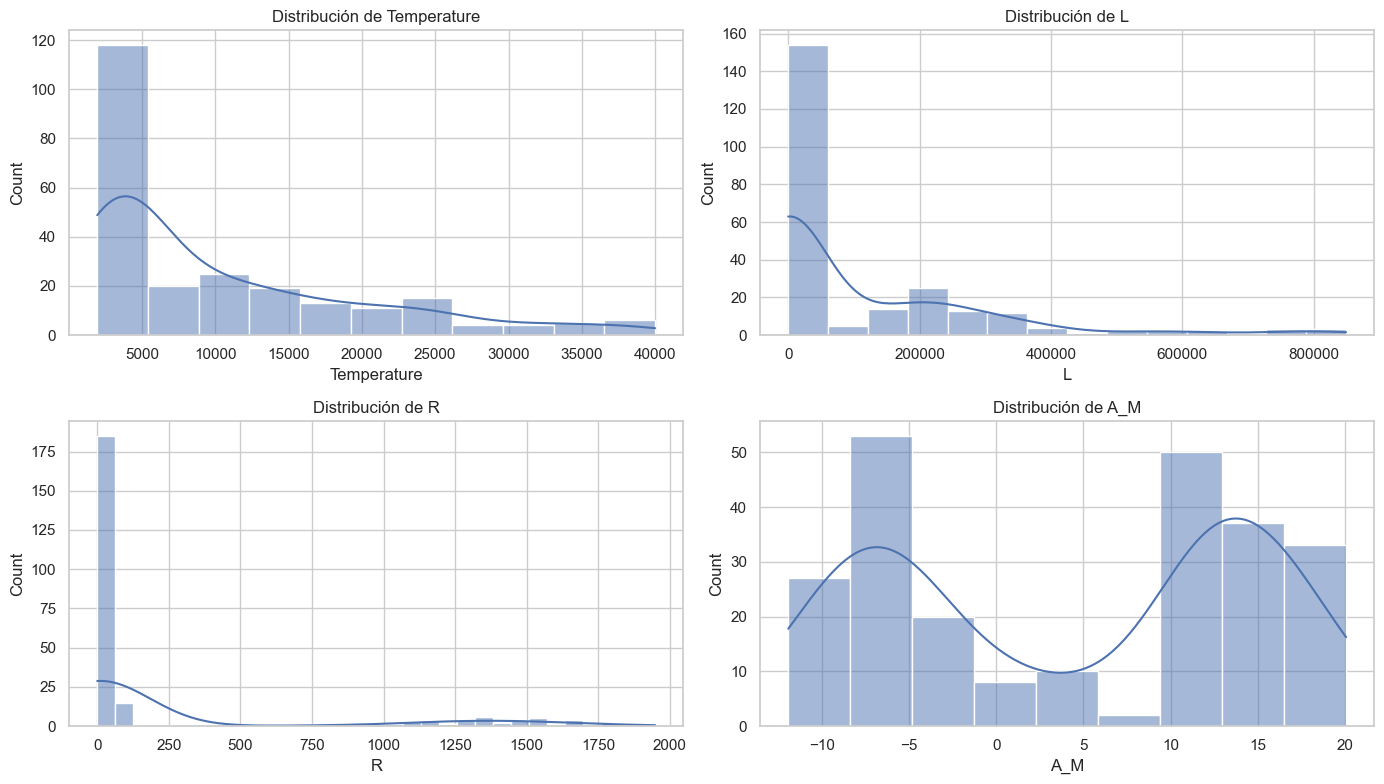

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

**Conclusión**: Las distribuciones de `Temperature`, `L` y `R` muestran una clara asimetría positiva, con gran concentración de estrellas en valores bajos y una cola larga hacia valores altos. Esto sugiere la existencia de observaciones extremas que podrían influir en el clustering. Por su parte, `A_M` presenta una distribución menos concentrada y parece reflejar varios grupos de estrellas con comportamientos distintos.

## 1.5 Detección visual de valores atípicos

Tras analizar la distribución de las variables numéricas, resulta útil estudiar la posible presencia de valores atípicos mediante diagramas de caja. Este análisis permite identificar observaciones extremas y valorar su impacto potencial en técnicas posteriores como PCA y clustering.

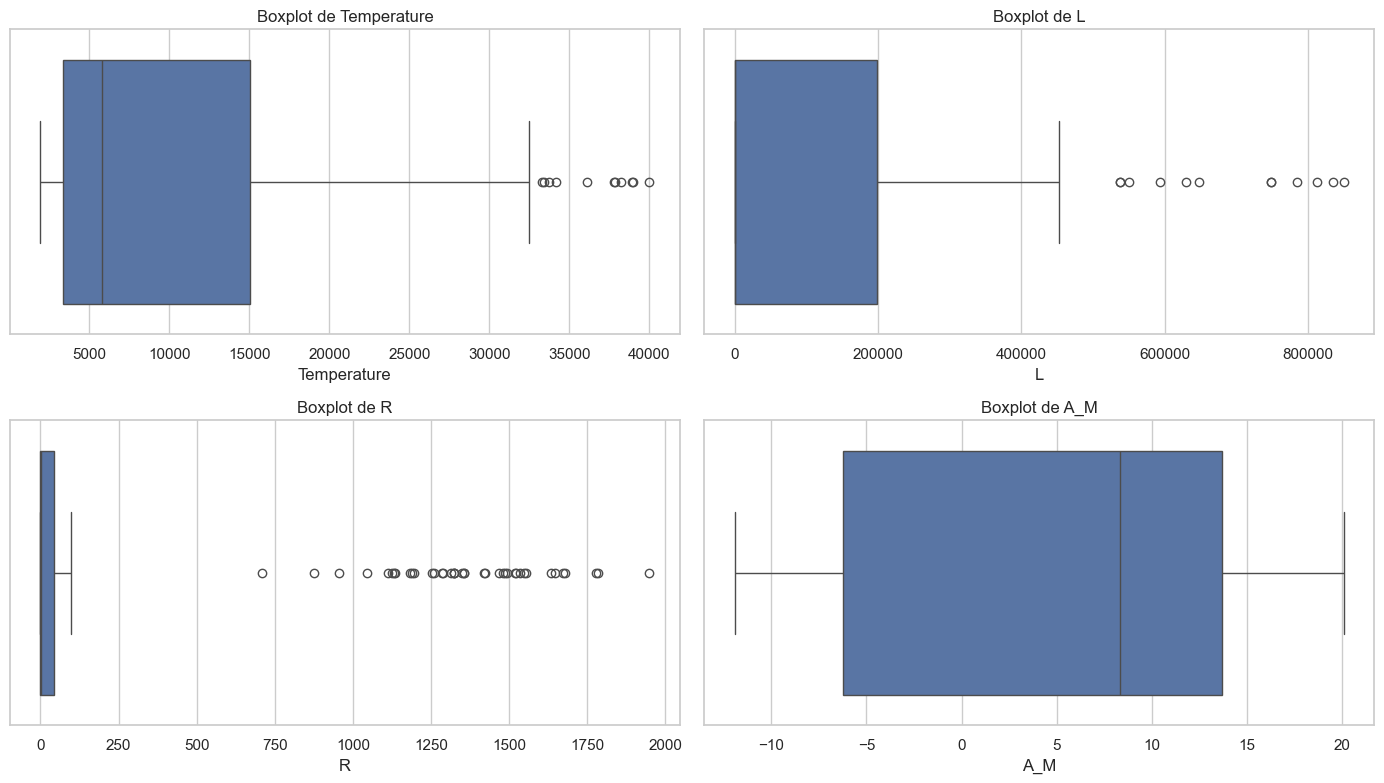

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

**Conclusión**: Los boxplots muestran la presencia de valores atípicos, especialmente en `L` y `R`, y en menor medida en `Temperature`. Esto indica que existen estrellas con características muy extremas respecto al resto del conjunto. En cambio, `A_M` presenta una distribución más estable. Dado el contexto del problema, estos valores extremos no deben considerarse necesariamente errores, sino posibles observaciones relevantes para la formación de grupos.

## 1.6 Análisis de variables categóricas

En este apartado se estudian las variables categóricas `Color` y `Spectral_Class`. El objetivo es conocer sus valores posibles, su frecuencia y detectar posibles inconsistencias en el etiquetado. Este paso es especialmente importante, ya que ambas variables deberán codificarse posteriormente de forma ordinal, respetando su relación con la energía.

In [7]:
cat_cols = ["Color", "Spectral_Class"]

for col in cat_cols:
    print(f"\nFrecuencias de {col}:")
    display(df[col].value_counts())
    print(f"Valores únicos en {col}: {df[col].nunique()}")


Frecuencias de Color:


Color
Red                   112
Blue                   56
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Blue white              4
Yellowish White         3
white                   3
Whitish                 2
Orange                  2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Yellowish               1
Orange-Red              1
Blue-White              1
Name: count, dtype: int64

Valores únicos en Color: 17

Frecuencias de Spectral_Class:


Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64

Valores únicos en Spectral_Class: 7


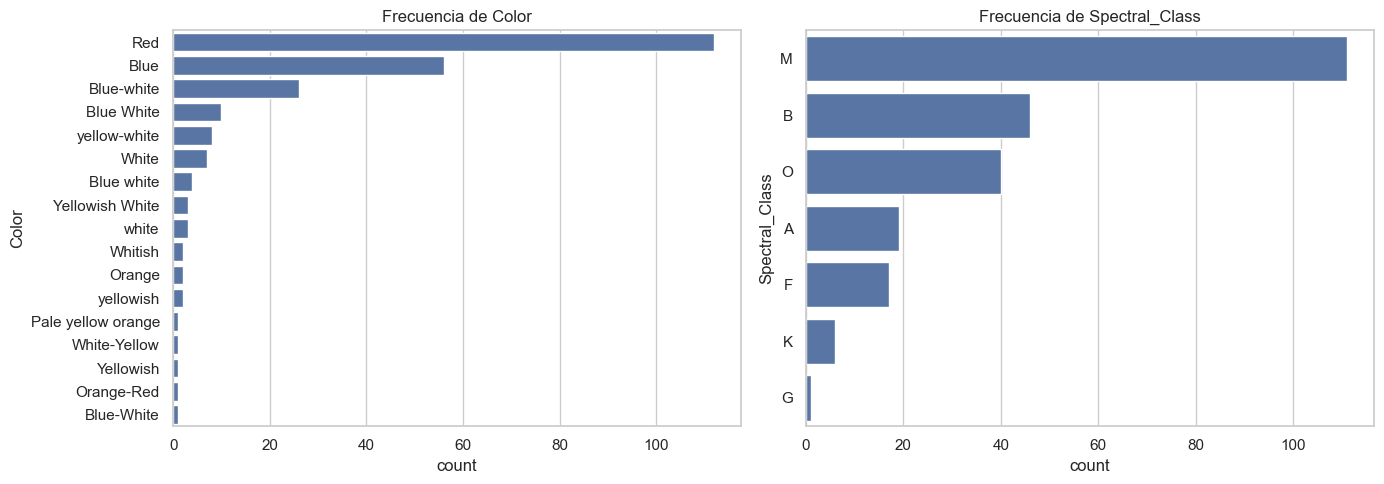

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(f"Frecuencia de {col}")

plt.tight_layout()
plt.show()

**Conclusión**: El análisis de las variables categóricas muestra que `Color` y `Spectral_Class` presentan un número reducido de categorías, aunque con una distribución desigual. En `Color` se observan además varias inconsistencias de escritura, como diferencias entre mayúsculas, espacios y guiones, por lo que será necesario unificar estas etiquetas antes de realizar la codificación ordinal. Por su parte, `Spectral_Class` presenta un claro predominio de algunas clases, especialmente `M`.

## 1.7 Relación entre variables numéricas

Una vez analizadas las distribuciones individuales, resulta útil estudiar la relación entre las variables numéricas mediante una matriz de correlación. Esto permite identificar dependencias lineales entre atributos y valorar si existe información redundante, algo relevante de cara a la aplicación posterior de PCA.

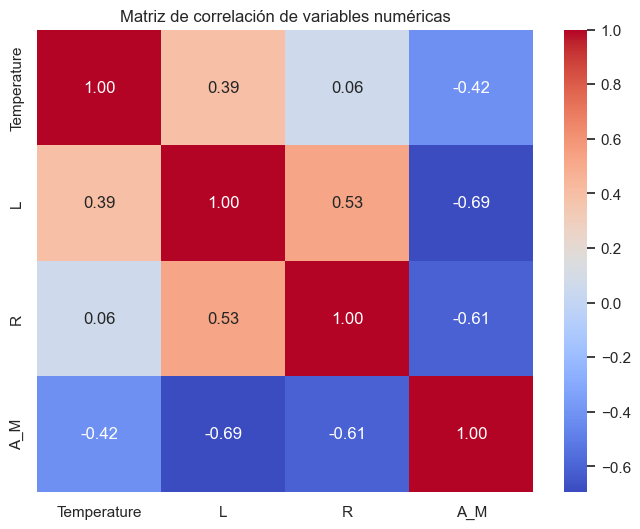

In [9]:
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación de variables numéricas")
plt.show()

**Conclusión**: La matriz de correlación muestra que existen relaciones relevantes entre varias variables numéricas. En particular, `L` y `R` presentan una correlación positiva moderada, mientras que `A_M` se relaciona de forma negativa con ambas. Esto indica que parte de la información está compartida entre variables, lo que justifica el uso posterior de PCA para reducir dimensionalidad.

## 1.8 Conclusiones del EDA

- El dataset contiene 240 estrellas y 6 variables, sin valores nulos ni duplicados.
- Las variables numéricas presentan escalas muy diferentes, especialmente `L` y `R`.
- En `Temperature`, `L` y `R` se observan distribuciones asimétricas y valores extremos.
- `Color` y `Spectral_Class` son variables categóricas con significado ordinal, ya que están relacionadas con la energía de la estrella.
- En `Color` aparecen varias inconsistencias de escritura, por lo que será necesario unificar etiquetas antes de codificar.
- La correlación entre algunas variables numéricas justifica aplicar PCA para reducir dimensionalidad antes del clustering.
- En conjunto, el EDA confirma que el siguiente paso debe ser el preprocesado: limpieza de categorías, codificación ordinal, estandarización y PCA a 2 componentes.

## 2. Preprocesado de los datos

En este apartado se prepara el dataset para aplicar las técnicas de clustering. Para ello, primero se revisan y limpian las variables categóricas, después se realiza su codificación ordinal y, finalmente, se estandarizan los datos y se aplica PCA a 2 componentes principales.

### 2.1 Revisión de categorías

Antes de codificar las variables categóricas, se revisan sus valores únicos para detectar posibles inconsistencias en el etiquetado. Este paso es especialmente importante en `Color`, donde durante el EDA ya se observaron diferencias en mayúsculas, espacios y guiones.

In [10]:
print("Valores únicos de Color:")
print(sorted(df["Color"].unique()))

print("\nValores únicos de Spectral_Class:")
print(sorted(df["Spectral_Class"].unique()))

Valores únicos de Color:
['Blue', 'Blue White', 'Blue white', 'Blue-White', 'Blue-white', 'Orange', 'Orange-Red', 'Pale yellow orange', 'Red', 'White', 'White-Yellow', 'Whitish', 'Yellowish', 'Yellowish White', 'white', 'yellow-white', 'yellowish']

Valores únicos de Spectral_Class:
['A', 'B', 'F', 'G', 'K', 'M', 'O']


**Conclusión**: La revisión de valores únicos confirma que `Color` contiene varias etiquetas equivalentes escritas de forma distinta, por lo que será necesario unificarlas antes de la codificación. En cambio, `Spectral_Class` presenta categorías limpias y bien definidas.

### 2.2 Limpieza de la variable `Color`

Se unifican las distintas formas de escribir una misma categoría en la variable `Color`. De este modo, se evitan duplicidades artificiales y se asegura una codificación ordinal coherente.

In [11]:
df_clean = df.copy()

color_mapping = {
    "Red": "Red",
    "Orange-Red": "Orange-Red",
    "Orange": "Orange",
    "Pale yellow orange": "Pale Yellow Orange",
    "yellowish": "Yellowish",
    "Yellowish": "Yellowish",
    "yellow-white": "Yellow-White",
    "White-Yellow": "Yellow-White",
    "White": "White",
    "white": "White",
    "Whitish": "Whitish",
    "Yellowish White": "Yellowish White",
    "Blue-white": "Blue-White",
    "Blue white": "Blue-White",
    "Blue White": "Blue-White",
    "Blue-White": "Blue-White",
    "Blue": "Blue"
}

df_clean["Color"] = df_clean["Color"].str.strip().replace(color_mapping)

print("Valores únicos de Color tras la limpieza:")
print(sorted(df_clean["Color"].unique()))

Valores únicos de Color tras la limpieza:
['Blue', 'Blue-White', 'Orange', 'Orange-Red', 'Pale Yellow Orange', 'Red', 'White', 'Whitish', 'Yellow-White', 'Yellowish', 'Yellowish White']


**Conclusión**: Tras la limpieza, la variable `Color` queda formada por un conjunto de categorías más consistente y sin duplicidades debidas a diferencias de escritura. Esto permitirá aplicar una codificación ordinal más fiable.

### 2.3 Codificación ordinal de `Spectral_Class`

La variable `Spectral_Class` tiene carácter ordinal, ya que sigue una secuencia física asociada a la energía y temperatura de las estrellas. En astronomía, las clases espectrales se ordenan de las más frías a las más calientes como `M-K-G-F-A-B-O`, por lo que se realizará una codificación respetando dicho orden.

In [12]:
spectral_mapping = {
    "M": 0,
    "K": 1,
    "G": 2,
    "F": 3,
    "A": 4,
    "B": 5,
    "O": 6
}

df_clean["Spectral_Class_ord"] = df_clean["Spectral_Class"].map(spectral_mapping)

display(df_clean[["Spectral_Class", "Spectral_Class_ord"]].drop_duplicates().sort_values("Spectral_Class_ord"))
print("Valores nulos tras la codificación:", df_clean["Spectral_Class_ord"].isna().sum())

,Spectral_Class,Spectral_Class_ord
0,M,0
91,K,1
118,G,2
22,F,3
21,A,4
20,B,5
30,O,6


Valores nulos tras la codificación: 0


**Conclusión:** La variable `Spectral_Class` ha quedado transformada en una escala ordinal coherente con su significado físico, lo que permitirá incorporarla al análisis sin perder la información asociada al orden entre categorías.

### 2.4 Codificación ordinal de `Color`

Una vez unificadas las categorías de `Color`, se realiza su codificación ordinal para poder incorporar esta variable al análisis numérico. Aunque a simple vista pueda parecer una variable meramente descriptiva, en este contexto el color del espectro está relacionado con propiedades físicas de la estrella, como su energía o temperatura.

Por ello, no resulta adecuado tratar `Color` como una categoría cualquiera sin orden. En su lugar, se establece una progresión aproximada desde tonos rojizos, asociados a menor energía, hasta tonos azulados, asociados a mayor energía. De este modo, la variable puede utilizarse posteriormente en PCA y en los algoritmos de clustering conservando parte de su significado físico.

In [13]:
color_mapping_ord = {
    "Red": 0,
    "Orange-Red": 1,
    "Orange": 2,
    "Pale Yellow Orange": 3,
    "Yellowish": 4,
    "Yellow-White": 5,
    "Whitish": 6,
    "Yellowish White": 7,
    "White": 8,
    "Blue-White": 9,
    "Blue": 10
}

df_clean["Color_ord"] = df_clean["Color"].map(color_mapping_ord)

display(df_clean[["Color", "Color_ord"]].drop_duplicates().sort_values("Color_ord"))
print("Valores nulos tras la codificación:", df_clean["Color_ord"].isna().sum())

,Color,Color_ord
0,Red,0
96,Orange-Red,1
53,Orange,2
29,Pale Yellow Orange,3
91,Yellowish,4
34,Yellow-White,5
33,Whitish,6
25,Yellowish White,7
21,White,8
20,Blue-White,9


Valores nulos tras la codificación: 0


**Conclusión:** La variable `Color` queda representada mediante una escala ordinal coherente con la progresión energética del espectro, lo que permite incorporarla al análisis numérico posterior.

### 2.5 Construcción del dataset final

Una vez codificadas las variables categóricas, se construye el conjunto de datos que se utilizará en las siguientes etapas del análisis. En este nuevo dataset se reúnen las variables numéricas originales junto con las versiones ordinales de `Color` y `Spectral_Class`, de modo que toda la información relevante quede representada de forma numérica.

In [14]:
features = ["Temperature", "L", "R", "A_M", "Color_ord", "Spectral_Class_ord"]

X = df_clean[features].copy()

display(X.head())
print("Dimensiones del dataset final:", X.shape)

,Temperature,L,R,A_M,Color_ord,Spectral_Class_ord
0,3068,0.002400,0.1700,16.12,0,0
1,3042,0.000500,0.1542,16.60,0,0
2,2600,0.000300,0.1020,18.70,0,0
3,2800,0.000200,0.1600,16.65,0,0
4,1939,0.000138,0.1030,20.06,0,0


Dimensiones del dataset final: (240, 6)


**Conclusión:** En este punto ya se dispone de un conjunto de datos completamente numérico, preparado para aplicar las transformaciones previas al clustering.

### 2.6 Estandarización de variables

Antes de aplicar PCA y los algoritmos de clustering, es necesario estandarizar las variables. Esto se debe a que no todas están medidas en la misma escala: por ejemplo, `Temperature`, `L` y `R` toman valores muy distintos respecto a las variables codificadas ordinalmente.

Si no se realizara esta transformación, las variables con mayor magnitud podrían dominar el análisis y condicionar en exceso la formación de los grupos. Por ello, se utiliza una estandarización que centra cada variable en media 0 y desviación típica 1.

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)

display(X_scaled_df.head())

,Temperature,L,R,A_M,Color_ord,Spectral_Class_ord
0,-0.779382,-0.598624,-0.459210,1.116745,-1.014108,-0.997781
1,-0.782110,-0.598624,-0.459241,1.162414,-1.014108,-0.997781
2,-0.828477,-0.598624,-0.459342,1.362213,-1.014108,-0.997781
3,-0.807496,-0.598624,-0.459229,1.167171,-1.014108,-0.997781
4,-0.897819,-0.598624,-0.459340,1.491607,-1.014108,-0.997781


**Conclusión:** Se utiliza `StandardScaler` para estandarizar las variables antes de aplicar PCA y clustering, ya que presentan escalas muy diferentes. Dado que el enunciado no exige comparar distintos métodos de escalado, se utiliza `StandardScaler` por ser una opción habitual y adecuada antes de aplicar PCA y clustering, pero podria ser modificada.

### 2.7 Reducción de dimensionalidad mediante PCA

Para facilitar la visualización de los datos y aplicar posteriormente los algoritmos de clustering, se reduce el dataset a dos dimensiones mediante PCA. Esta transformación permite proyectar cada estrella en un espacio bidimensional conservando, en la medida de lo posible, la mayor cantidad de información del conjunto original.

In [16]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

display(df_pca.head())

print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

,PC1,PC2
0,-2.070370,-0.146042
1,-2.089897,-0.163965
2,-2.191517,-0.234932
3,-2.103735,-0.160411
4,-2.275805,-0.272374


Varianza explicada por cada componente: [0.55431472 0.29696459]
Varianza explicada acumulada: 0.8512793111175818


**Representacion grafica**

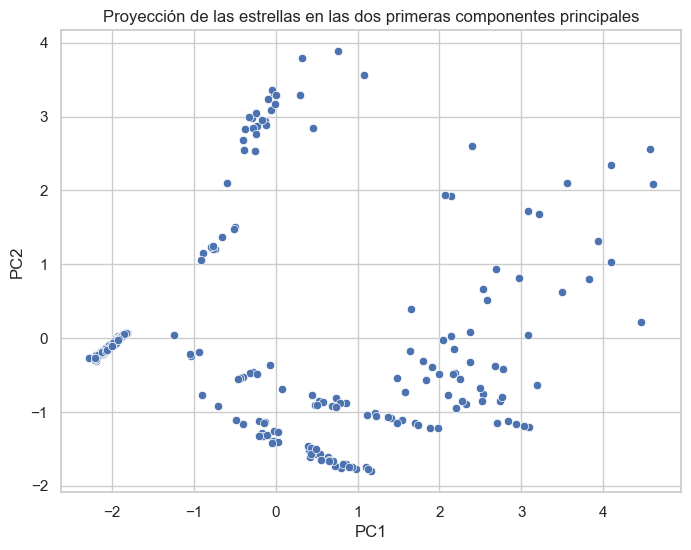

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2")
plt.title("Proyección de las estrellas en las dos primeras componentes principales")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**Conclusión:** Las dos primeras componentes principales explican aproximadamente el 85% de la variabilidad total del dataset, por lo que la representación en dos dimensiones conserva una parte importante de la información original. Además, en la proyección se observan zonas diferenciadas, lo que sugiere que puede haber grupos naturales de estrellas.

### Conclusión del preprocesado
Tras limpiar la variable `Color`, codificar ordinalmente las variables categóricas, estandarizar las características y reducir la dimensionalidad a dos componentes principales, el conjunto de datos queda preparado para aplicar y comparar los distintos algoritmos de clustering.

## 3. K-Means

K-Means es un algoritmo de clustering que agrupa las observaciones en un número fijo de clusters. Para utilizarlo es necesario elegir previamente el valor de `k`, es decir, el número de grupos que queremos obtener.

### 3.1 Selección del número de clusters

En este apartado se prueban distintos valores de `k` y se comparan mediante dos criterios: la inercia y el coeficiente de silhouette. La inercia mide la compactación de los clusters, mientras que silhouette permite evaluar si los puntos están bien asignados a su grupo.

In [18]:
k_values = range(2, 11)

inertias = []
silhouettes = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

kmeans_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette": silhouettes
})

display(kmeans_results)

,k,inertia,silhouette
0,2,603.445187,0.519116
1,3,334.212078,0.591750
2,4,169.433969,0.634718
3,5,105.288298,0.646905
4,6,81.519568,0.656079
5,7,63.304182,0.637676
6,8,54.205616,0.630307
7,9,47.603811,0.604135
8,10,42.529849,0.617263


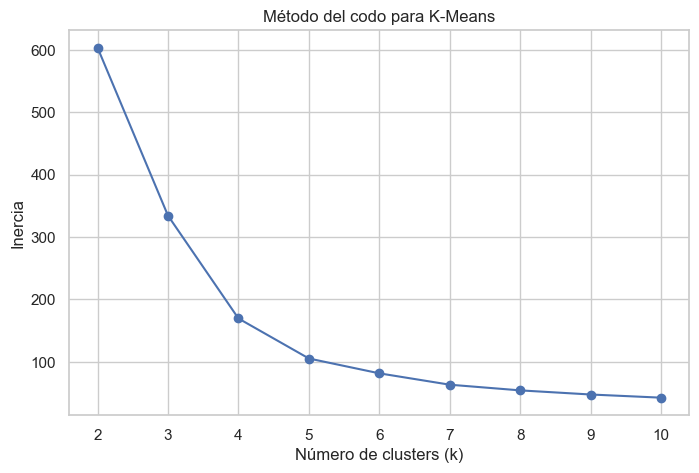

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(kmeans_results["k"], kmeans_results["inertia"], marker="o")
plt.title("Método del codo para K-Means")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.show()

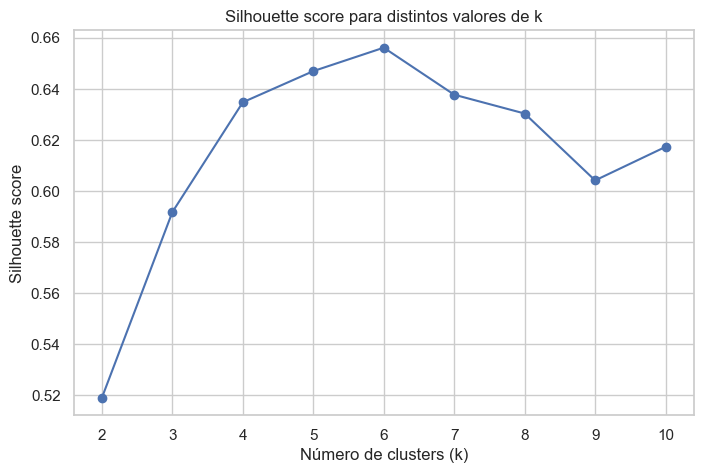

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(kmeans_results["k"], kmeans_results["silhouette"], marker="o")
plt.title("Silhouette score para distintos valores de k")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")
plt.show()

**Conclusión:**  El método del codo muestra una reducción fuerte de la inercia hasta valores cercanos a `k = 5` o `k = 6`, a partir de los cuales la mejora empieza a ser menor. Por otro lado, el coeficiente silhouette alcanza su valor más alto para `k = 6`. Por este motivo, se selecciona `k = 6` como número de clusters para el modelo final de K-Means.

### 3.2 Modelo final K-Means

Tras comparar distintos valores de `k` mediante el método del codo y el coeficiente silhouette, se selecciona `k = 6` para entrenar el modelo final de K-Means.

In [21]:
best_k = 6

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=SEED,
    n_init=10
)

labels_kmeans = kmeans_final.fit_predict(X_pca)

df_pca["Cluster_KMeans"] = labels_kmeans

display(df_pca.head())

,PC1,PC2,Cluster_KMeans
0,-2.070370,-0.146042,0
1,-2.089897,-0.163965,0
2,-2.191517,-0.234932,0
3,-2.103735,-0.160411,0
4,-2.275805,-0.272374,0


### 3.3 Evaluación del resultado

In [22]:
silhouette_kmeans_final = silhouette_score(X_pca, labels_kmeans)

print("Silhouette final de K-Means:", silhouette_kmeans_final)

print("\nNúmero de estrellas por cluster:")
display(df_pca["Cluster_KMeans"].value_counts().sort_index().to_frame("n_estrellas"))

Silhouette final de K-Means: 0.6560794726289759

Número de estrellas por cluster:


,n_estrellas
Cluster_KMeans,
0,85
1,42
2,10
3,61
4,18
5,24


### 3.4 Visualización de clusters

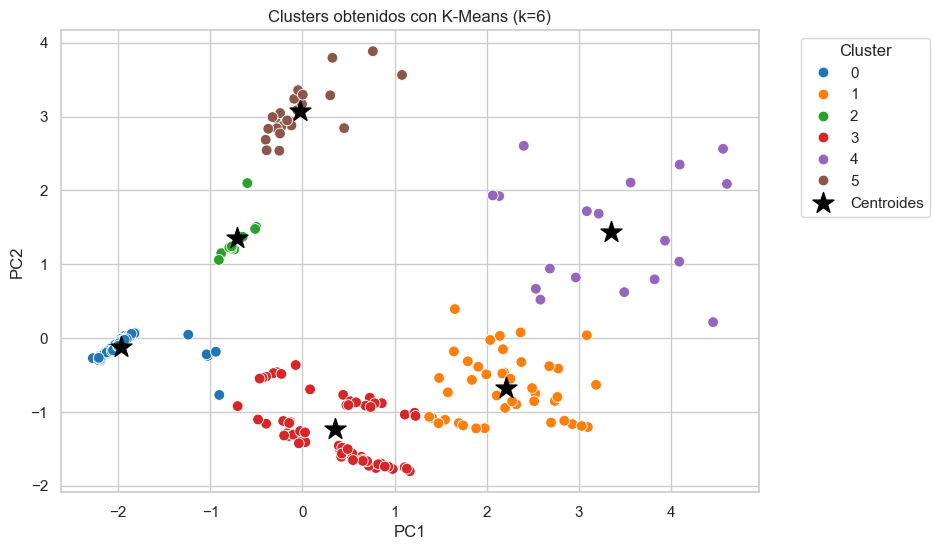

In [23]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Cluster_KMeans",
    palette="tab10",
    s=60
)

plt.scatter(
    kmeans_final.cluster_centers_[:, 0],
    kmeans_final.cluster_centers_[:, 1],
    c="black",
    marker="*",
    s=250,
    label="Centroides"
)

plt.title("Clusters obtenidos con K-Means (k=6)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

**Conclusión:** K-Means divide las estrellas en seis grupos diferenciados sobre el espacio definido por las dos componentes principales. La elección de `k = 6` queda apoyada por el valor máximo de silhouette y por el comportamiento observado en el método del codo. Visualmente, los clusters aparecen bastante separados, aunque algunos presentan mayor dispersión. Este resultado se tomará como primera referencia para compararlo posteriormente con clustering jerárquico y DBSCAN.

## 4. Clustering jerárquico

El clustering jerárquico es un método de agrupamiento que construye una estructura en forma de árbol, llamada dendrograma. A diferencia de K-Means, no parte inicialmente de un número fijo de centroides, sino que va uniendo observaciones o grupos de observaciones en función de su similitud.

En esta práctica se aplicará clustering jerárquico sobre las dos componentes principales obtenidas mediante PCA. Para tomar una decisión razonada, se compararán distintas funciones de linkage y distintos números de clusters utilizando el coeficiente silhouette.

### 4.1 Comparación de funciones de linkage

La función de linkage determina cómo se mide la distancia entre grupos durante el proceso jerárquico. Como esta elección puede afectar al resultado final, se comparan varias opciones y se evalúa su comportamiento mediante el coeficiente silhouette para distintos números de clusters.

In [24]:
linkage_methods = ["ward", "complete", "average", "single"]
n_clusters_range = range(2, 11)

hierarchical_results = []

for linkage_method in linkage_methods:
    for n_clusters in n_clusters_range:
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage=linkage_method
        )
        
        labels = model.fit_predict(X_pca)
        sil_score = silhouette_score(X_pca, labels)
        
        hierarchical_results.append({
            "linkage": linkage_method,
            "n_clusters": n_clusters,
            "silhouette": sil_score
        })

hierarchical_results = pd.DataFrame(hierarchical_results)

display(
    hierarchical_results.sort_values(
        by="silhouette",
        ascending=False
    ).head(10)
)

,linkage,n_clusters,silhouette
5,ward,7,0.633219
21,average,5,0.630961
24,average,8,0.629394
23,average,7,0.627937
4,ward,6,0.623178
22,average,6,0.622510
25,average,9,0.621510
20,average,4,0.616876
26,average,10,0.615435
2,ward,4,0.602342


**Conclusión:**  
La comparación de distintas funciones de linkage y números de clusters muestra que la mejor configuración para el clustering jerárquico es `ward` con 7 clusters, obteniendo el mayor coeficiente silhouette. Aunque otras configuraciones, como `average` con 5 clusters, presentan valores muy cercanos, se selecciona `ward` con 7 clusters al ser la opción con mejor resultado según la métrica utilizada.

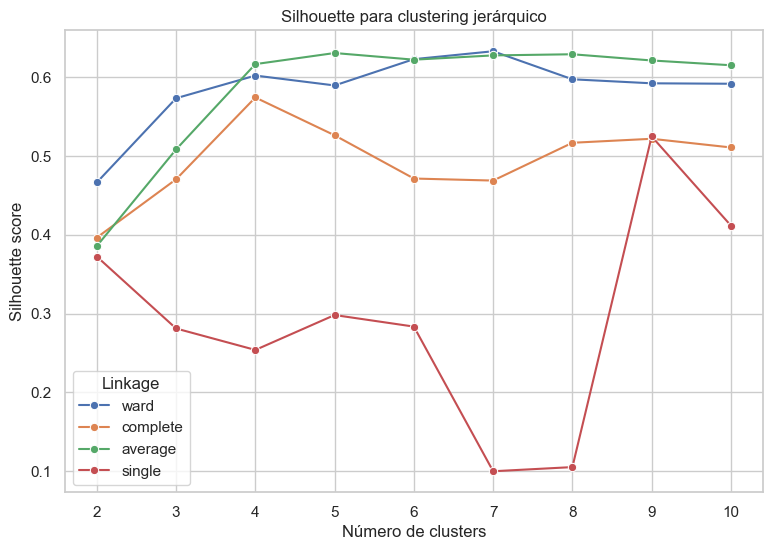

In [25]:
plt.figure(figsize=(9, 6))

sns.lineplot(
    data=hierarchical_results,
    x="n_clusters",
    y="silhouette",
    hue="linkage",
    marker="o"
)

plt.title("Silhouette para clustering jerárquico")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette score")
plt.legend(title="Linkage")
plt.show()

**Conclusión:** El gráfico muestra que los métodos `ward` y `average` obtienen los mejores resultados de forma general, mientras que `single` presenta un comportamiento más inestable. La mejor puntuación se obtiene con `ward` y 7 clusters.

### 4.3 Selección de la configuración final

A partir de la comparación anterior, se selecciona la combinación de función de linkage y número de clusters que obtiene el mayor coeficiente silhouette. Esta configuración se utilizará para construir el dendrograma y entrenar el modelo final de clustering jerárquico.

In [26]:
best_hierarchical = hierarchical_results.loc[
    hierarchical_results["silhouette"].idxmax()
]

best_linkage = best_hierarchical["linkage"]
best_n_clusters_hierarchical = int(best_hierarchical["n_clusters"])
best_silhouette_hierarchical = best_hierarchical["silhouette"]

print("Mejor linkage:", best_linkage)
print("Mejor número de clusters:", best_n_clusters_hierarchical)
print("Silhouette:", best_silhouette_hierarchical)

Mejor linkage: ward
Mejor número de clusters: 7
Silhouette: 0.6332191704419151


### 4.4 Dendrograma

El dendrograma permite visualizar cómo se van fusionando las observaciones y los grupos a medida que aumenta la distancia de unión. Esta representación ayuda a interpretar la estructura jerárquica de los datos y a valorar si el número de clusters seleccionado resulta coherente.

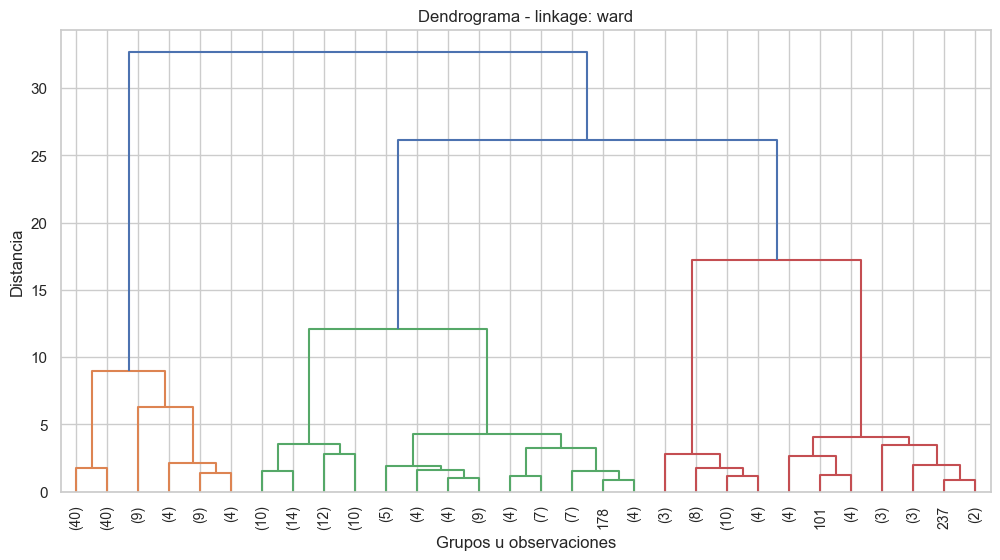

In [27]:
Z = linkage(X_pca, method=best_linkage)

plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title(f"Dendrograma - linkage: {best_linkage}")
plt.xlabel("Grupos u observaciones")
plt.ylabel("Distancia")
plt.show()

**Conclusión:**  
El dendrograma obtenido con linkage `ward` muestra una estructura jerárquica clara, con varias fusiones que se producen a distancias elevadas. Esto indica que existen grupos diferenciados en los datos. La visualización es coherente con la selección previa de 7 clusters mediante silhouette, aunque el dendrograma también muestra que algunas agrupaciones están más separadas que otras.

### 4.5 Selección visual mediante el dendrograma

Además de utilizar silhouette para comparar configuraciones, se analiza el dendrograma como apoyo visual. En clustering jerárquico, cada fusión entre grupos se produce a una determinada altura, que representa la distancia necesaria para unirlos.

Un salto grande entre alturas consecutivas indica que, a partir de ese punto, el algoritmo necesita unir grupos bastante más diferentes entre sí. Por ello, una forma habitual de decidir el número de clusters consiste en cortar el dendrograma antes de ese gran salto.

En este trabajo se utiliza silhouette como criterio principal de selección, y el dendrograma se emplea como herramienta complementaria para comprobar que la estructura obtenida es coherente.

In [28]:
from scipy.cluster.hierarchy import fcluster

# Matriz de enlace con el linkage seleccionado
Z = linkage(X_pca, method=best_linkage)

# Alturas de fusión
heights = Z[:, 2]

# Diferencias entre alturas consecutivas
diffs = np.diff(heights)

# Índice del mayor salto
idx_max_jump = np.argmax(diffs)

# Altura antes del mayor salto
altura_optima = heights[idx_max_jump]

print(f"Altura de corte sugerida por mayor salto: {altura_optima:.2f}")

Altura de corte sugerida por mayor salto: 17.19


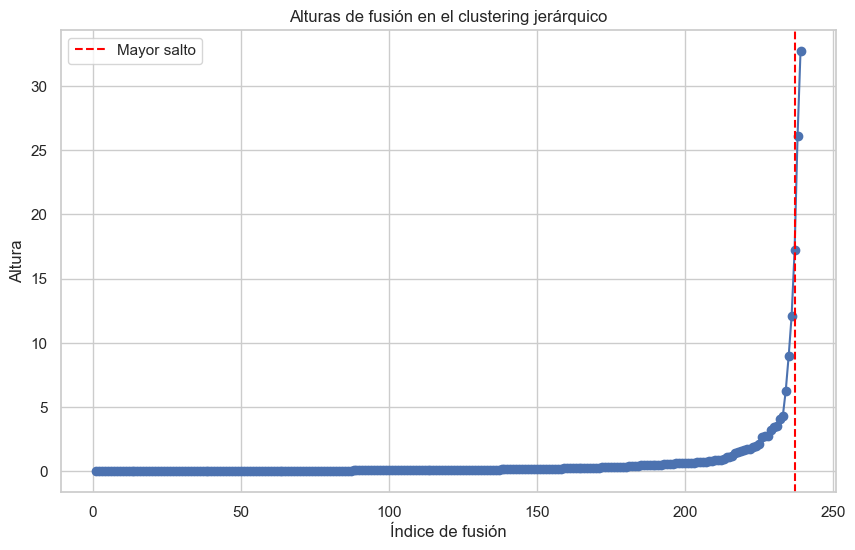

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, len(heights) + 1), heights, marker="o", linestyle="-")
plt.axvline(idx_max_jump + 1, color="red", linestyle="--", label="Mayor salto")

plt.title("Alturas de fusión en el clustering jerárquico")
plt.xlabel("Índice de fusión")
plt.ylabel("Altura")
plt.legend()
plt.show()

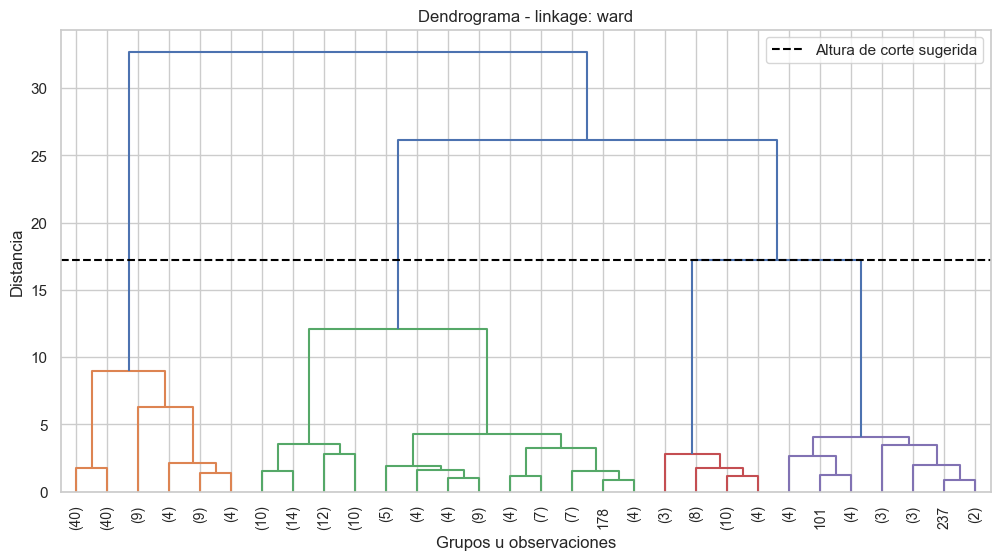

In [30]:
plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=altura_optima
)

plt.axhline(
    y=altura_optima,
    color="black",
    linestyle="--",
    label="Altura de corte sugerida"
)

plt.title(f"Dendrograma - linkage: {best_linkage}")
plt.xlabel("Grupos u observaciones")
plt.ylabel("Distancia")
plt.legend()
plt.show()

**Conclusión:**  
El análisis de las alturas de fusión muestra que las últimas uniones se producen a distancias bastante mayores, lo que indica la existencia de grupos diferenciados. Esta información sirve como apoyo visual al dendrograma, aunque en este trabajo la selección final del número de clusters se mantiene basada en silhouette.

### 4.6 Modelo final y evaluación del clustering jerárquico

Una vez seleccionada la configuración final, se entrena el modelo de clustering jerárquico utilizando `ward` como función de linkage y 7 clusters. Esta configuración fue elegida a partir del coeficiente silhouette obtenido en la comparación previa.

Tras entrenar el modelo, se evalúa el resultado mediante el valor final de silhouette y se analiza el número de estrellas asignadas a cada cluster.

In [31]:
hierarchical_final = AgglomerativeClustering(
    n_clusters=best_n_clusters_hierarchical,
    linkage=best_linkage
)

labels_hierarchical = hierarchical_final.fit_predict(X_pca)

df_pca["Cluster_Hierarchical"] = labels_hierarchical

display(df_pca.head())

,PC1,PC2,Cluster_KMeans,Cluster_Hierarchical
0,-2.070370,-0.146042,0,5
1,-2.089897,-0.163965,0,5
2,-2.191517,-0.234932,0,5
3,-2.103735,-0.160411,0,5
4,-2.275805,-0.272374,0,5


In [32]:
silhouette_hierarchical_final = silhouette_score(X_pca, labels_hierarchical)

print("Silhouette final de clustering jerárquico:", silhouette_hierarchical_final)

print("\nNúmero de estrellas por cluster:")
display(
    df_pca["Cluster_Hierarchical"]
    .value_counts()
    .sort_index()
    .to_frame("n_estrellas")
)

Silhouette final de clustering jerárquico: 0.6332191704419151

Número de estrellas por cluster:


,n_estrellas
Cluster_Hierarchical,
0,45
1,46
2,18
3,25
4,17
5,80
6,9


**Conclusión:**  
El modelo jerárquico final obtiene un coeficiente silhouette de aproximadamente 0.633, lo que indica una separación razonable entre los grupos. La partición generada contiene 7 clusters, aunque no todos tienen el mismo tamaño: algunos grupos concentran muchas más estrellas que otros. Este resultado sigue siendo coherente con el problema, ya que no todos los tipos de estrellas tienen por qué aparecer con la misma frecuencia en el dataset.

### 4.7 Visualización del clustering jerárquico

Finalmente, se representan los clusters obtenidos sobre el plano definido por las dos componentes principales. Esta visualización permite analizar si los grupos generados por el modelo aparecen separados de forma clara en el espacio PCA.

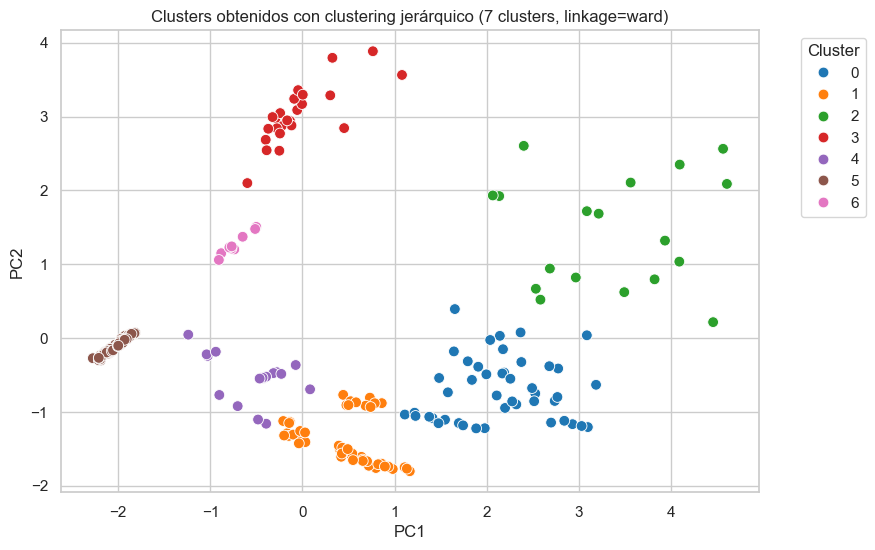

In [33]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Cluster_Hierarchical",
    palette="tab10",
    s=60
)

plt.title(
    f"Clusters obtenidos con clustering jerárquico "
    f"({best_n_clusters_hierarchical} clusters, linkage={best_linkage})"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

**Conclusión:**  
En comparación con K-Means, el resultado es similar, aunque el clustering jerárquico divide algunas regiones en más grupos, lo que explica que la mejor configuración encontrada tenga 7 clusters.

## 5. DBSCAN

DBSCAN es un algoritmo de clustering basado en densidad. A diferencia de K-Means o del clustering jerárquico, no necesita fijar directamente el número de clusters, sino que identifica regiones donde los puntos están suficientemente próximos entre sí.

Este método utiliza dos hiperparámetros principales: `eps`, que define la distancia máxima para considerar vecinos a dos puntos, y `min_samples`, que indica el número mínimo de puntos necesarios para formar una zona densa. Además, DBSCAN puede etiquetar como ruido aquellos puntos que no pertenecen claramente a ningún grupo.

### 5.1 Búsqueda de hiperparámetros

Para ajustar DBSCAN se prueban distintas combinaciones de `eps` y `min_samples`. Cada configuración se evalúa mediante la métrica DBCV, que está pensada para valorar clusters basados en densidad. También se registra el número de clusters obtenidos y el número de puntos considerados como ruido.

In [34]:
from hdbscan.validity import validity_index

eps_values = np.arange(0.1, 1.6, 0.1)
min_samples_values = range(3, 11)

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )
        
        labels = dbscan.fit_predict(X_pca)
        
        # Número de clusters sin contar ruido (-1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        
        # DBCV solo tiene sentido si hay al menos 2 clusters
        if n_clusters >= 2:
            try:
                dbcv_score = validity_index(X_pca.astype(np.float64), labels)
            except:
                dbcv_score = np.nan
        else:
            dbcv_score = np.nan
        
        dbscan_results.append({
            "eps": round(eps, 2),
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "dbcv": dbcv_score
        })

dbscan_results = pd.DataFrame(dbscan_results)

display(
    dbscan_results
    .dropna()
    .sort_values(by="dbcv", ascending=False)
    .head(10)
)

,eps,min_samples,n_clusters,n_noise,dbcv
35,0.5,6,4,26,0.660871
36,0.5,7,4,27,0.659276
37,0.5,8,4,27,0.659276
38,0.5,9,4,28,0.656563
9,0.2,4,11,52,0.635799
8,0.2,3,13,40,0.633407
20,0.3,7,10,47,0.628487
19,0.3,6,9,42,0.611030
10,0.2,5,9,65,0.606164
17,0.3,4,8,36,0.604696


### 5.2 Selección de la mejor configuración

Una vez evaluadas las distintas combinaciones de hiperparámetros, se selecciona aquella que obtiene el mayor valor de DBCV. Además de la métrica, se revisan el número de clusters y la cantidad de puntos etiquetados como ruido para comprobar que el resultado sea interpretable.

In [35]:
best_dbscan = dbscan_results.dropna().loc[
    dbscan_results.dropna()["dbcv"].idxmax()
]

best_eps = best_dbscan["eps"]
best_min_samples = int(best_dbscan["min_samples"])
best_dbcv = best_dbscan["dbcv"]
best_n_clusters_dbscan = int(best_dbscan["n_clusters"])
best_n_noise_dbscan = int(best_dbscan["n_noise"])

print("Mejor eps:", best_eps)
print("Mejor min_samples:", best_min_samples)
print("Número de clusters:", best_n_clusters_dbscan)
print("Número de puntos ruido:", best_n_noise_dbscan)
print("DBCV:", best_dbcv)

Mejor eps: 0.5
Mejor min_samples: 6
Número de clusters: 4
Número de puntos ruido: 26
DBCV: 0.660871208339492


**Conclusión:**  
La mejor configuración encontrada para DBSCAN es `eps = 0.5` y `min_samples = 6`, obteniendo 4 clusters y 26 puntos etiquetados como ruido. Esto indica que DBSCAN identifica menos grupos que K-Means y clustering jerárquico, pero permite detectar observaciones aisladas que no pertenecen claramente a ninguna zona densa. Aunque el resultado es interpretable, será necesario compararlo visualmente con los métodos anteriores.

### 5.3 Modelo final de DBSCAN

Con los hiperparámetros seleccionados mediante DBCV, se entrena el modelo final de DBSCAN sobre las dos componentes principales obtenidas mediante PCA.

El parámetro `metric` indica cómo se calcula la distancia entre observaciones. En este trabajo se utiliza la distancia euclídea, que es la opción por defecto en DBSCAN y resulta adecuada al trabajar sobre las dos componentes principales obtenidas mediante PCA.

In [36]:
dbscan_final = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

labels_dbscan = dbscan_final.fit_predict(X_pca)

df_pca["Cluster_DBSCAN"] = labels_dbscan

display(df_pca.head())

,PC1,PC2,Cluster_KMeans,Cluster_Hierarchical,Cluster_DBSCAN
0,-2.070370,-0.146042,0,5,0
1,-2.089897,-0.163965,0,5,0
2,-2.191517,-0.234932,0,5,0
3,-2.103735,-0.160411,0,5,0
4,-2.275805,-0.272374,0,5,0


In [37]:
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_dbscan = np.sum(labels_dbscan == -1)

dbcv_dbscan_final = validity_index(X_pca.astype(np.float64), labels_dbscan)

print("DBCV final de DBSCAN:", dbcv_dbscan_final)
print("Número de clusters:", n_clusters_dbscan)
print("Número de puntos ruido:", n_noise_dbscan)

print("\nNúmero de estrellas por cluster:")
display(
    df_pca["Cluster_DBSCAN"]
    .value_counts()
    .sort_index()
    .to_frame("n_estrellas")
)

DBCV final de DBSCAN: 0.660871208339492
Número de clusters: 4
Número de puntos ruido: 26

Número de estrellas por cluster:


,n_estrellas
Cluster_DBSCAN,
-1,26
0,80
1,103
2,9
3,22


**Conclusión:**  
DBSCAN obtiene una partición formada por 4 clusters y 26 puntos etiquetados como ruido. Esto indica que el algoritmo identifica varias zonas densas en el espacio PCA, pero también detecta estrellas aisladas que no asigna a ningún grupo. A diferencia de K-Means y clustering jerárquico, DBSCAN no fuerza a que todas las observaciones pertenezcan a un cluster, lo que puede ser útil para detectar posibles estrellas atípicas.

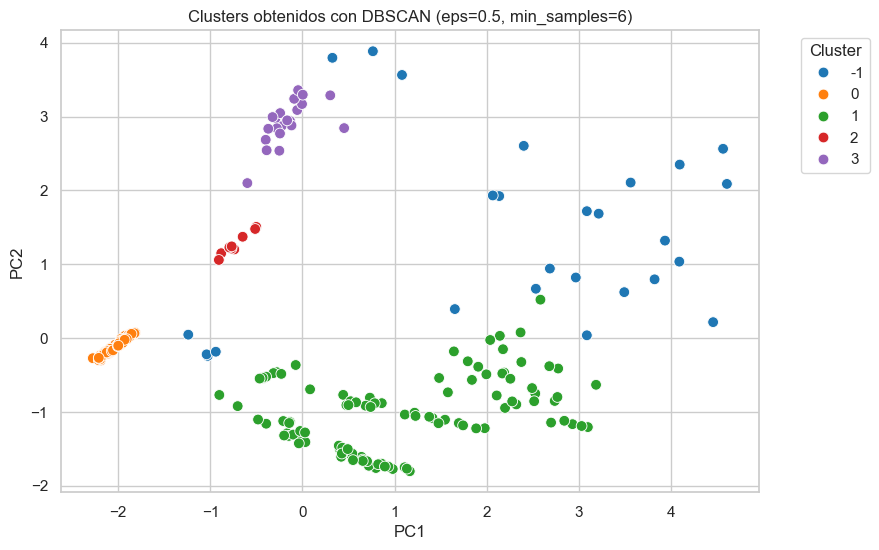

In [38]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Cluster_DBSCAN",
    palette="tab10",
    s=60
)

plt.title(
    f"Clusters obtenidos con DBSCAN "
    f"(eps={best_eps}, min_samples={best_min_samples})"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

**Conclusión:**  
Como ya hemos expuesto anteriormente tenemos los clusters ademas de los puntos independientes, demostrando la clasificacion realizada por DBSCAN.

## 6. Comparación de algoritmos y pipeline recomendado

Una vez aplicados los tres métodos de clustering, se comparan los resultados obtenidos. Para K-Means y clustering jerárquico se utiliza el coeficiente silhouette, mientras que para DBSCAN se utiliza DBCV, ya que es una métrica más adecuada para algoritmos basados en densidad.

Es importante tener en cuenta que silhouette y DBCV no son métricas directamente comparables entre sí, por lo que la elección final no se basará únicamente en el valor numérico, sino también en la interpretabilidad de los grupos obtenidos.

In [39]:
comparison_results = pd.DataFrame({
    "Algoritmo": [
        "K-Means",
        "Clustering jerárquico",
        "DBSCAN"
    ],
    "Configuración": [
        f"k = {best_k}",
        f"linkage = {best_linkage}, n_clusters = {best_n_clusters_hierarchical}",
        f"eps = {best_eps}, min_samples = {best_min_samples}"
    ],
    "Nº clusters": [
        best_k,
        best_n_clusters_hierarchical,
        n_clusters_dbscan
    ],
    "Métrica usada": [
        "Silhouette",
        "Silhouette",
        "DBCV"
    ],
    "Valor métrica": [
        silhouette_kmeans_final,
        silhouette_hierarchical_final,
        dbcv_dbscan_final
    ],
    "Puntos ruido": [
        0,
        0,
        n_noise_dbscan
    ]
})

display(comparison_results)

,Algoritmo,Configuración,Nº clusters,Métrica usada,Valor métrica,Puntos ruido
0,K-Means,k = 6,6,Silhouette,0.656079,0
1,Clustering jerárquico,"linkage = ward, n_clusters = 7",7,Silhouette,0.633219,0
2,DBSCAN,"eps = 0.5, min_samples = 6",4,DBCV,0.660871,26


**Conclusión:**  
K-Means obtiene el mejor valor de silhouette entre los métodos evaluados con esta métrica, generando 6 clusters diferenciados. El clustering jerárquico también ofrece un resultado razonable, aunque con un valor de silhouette algo menor y 7 clusters. Por su parte, DBSCAN identifica 4 clusters y 26 puntos como ruido, lo que resulta útil para detectar observaciones aisladas, aunque ofrece una partición menos detallada del conjunto de estrellas.

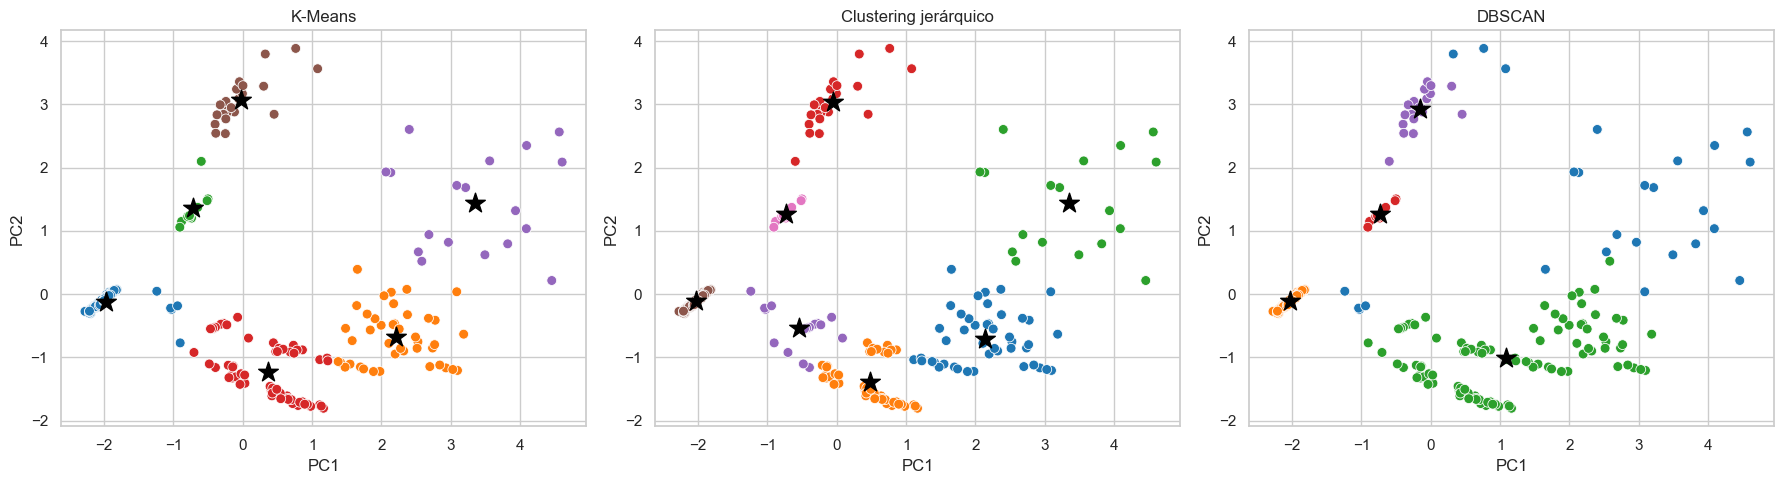

In [40]:
def plot_clusters_with_centers(ax, data, cluster_col, title, exclude_noise=False):
    sns.scatterplot(
        data=data,
        x="PC1",
        y="PC2",
        hue=cluster_col,
        palette="tab10",
        s=50,
        ax=ax,
        legend=False
    )
    
    # Para DBSCAN excluimos el ruido (-1) del cálculo del centro visual
    if exclude_noise:
        data_centers = data[data[cluster_col] != -1]
    else:
        data_centers = data.copy()
    
    centers = data_centers.groupby(cluster_col)[["PC1", "PC2"]].mean()
    
    ax.scatter(
        centers["PC1"],
        centers["PC2"],
        c="black",
        marker="*",
        s=220,
        label="Centro"
    )
    
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_clusters_with_centers(
    axes[0],
    df_pca,
    "Cluster_KMeans",
    "K-Means"
)

plot_clusters_with_centers(
    axes[1],
    df_pca,
    "Cluster_Hierarchical",
    "Clustering jerárquico"
)

plot_clusters_with_centers(
    axes[2],
    df_pca,
    "Cluster_DBSCAN",
    "DBSCAN",
    exclude_noise=True
)

plt.tight_layout()
plt.show()

**Conclusión:**  
La comparación visual muestra las particiones obtenidas por los tres algoritmos. Las estrellas negras indican el centro aproximado de cada cluster en el plano PCA. En K-Means estos centros corresponden a los centroides del modelo, mientras que en clustering jerárquico y DBSCAN se representan como centros medios visuales para facilitar la comparación. En DBSCAN no se calcula centro para el grupo `-1`, ya que corresponde a puntos etiquetados como ruido.

### 6.3 Pipeline recomendado

A partir de los resultados obtenidos, se recomienda utilizar el pipeline basado en K-Means con `k = 6`. Esta elección se justifica por varios motivos:

- Obtiene el mejor valor de silhouette entre los métodos evaluados con esta métrica.
- Genera grupos visualmente diferenciados en el espacio PCA.
- No deja observaciones sin asignar, a diferencia de DBSCAN.
- El número de clusters obtenido es interpretable y facilita la comparación posterior con las clases astronómicas de referencia.

Por tanto, el pipeline recomendado es:

1. Limpieza de la variable `Color`.
2. Codificación ordinal de `Color` y `Spectral_Class`.
3. Estandarización de las variables.
4. Reducción de dimensionalidad mediante PCA a 2 componentes.
5. Aplicación de K-Means con `k = 6`.

## 7. Caracterización de los clusters

Una vez seleccionado K-Means con `k = 6` como pipeline recomendado, se analizan los grupos obtenidos para interpretar qué tipo de estrellas contiene cada cluster. Para ello, se recuperan las variables originales y se añade la etiqueta de cluster asignada por K-Means.

In [41]:
df_clusters = df_clean.copy()
df_clusters["Cluster_KMeans"] = df_pca["Cluster_KMeans"]

display(df_clusters.head())

,Temperature,L,R,A_M,Color,Spectral_Class,Spectral_Class_ord,Color_ord,Cluster_KMeans
0,3068,0.002400,0.1700,16.12,Red,M,0,0,0
1,3042,0.000500,0.1542,16.60,Red,M,0,0,0
2,2600,0.000300,0.1020,18.70,Red,M,0,0,0
3,2800,0.000200,0.1600,16.65,Red,M,0,0,0
4,1939,0.000138,0.1030,20.06,Red,M,0,0,0


### 7.1 Resumen estadístico por cluster

Para comenzar la caracterización, se construye una tabla resumen de cada cluster obtenido con K-Means. Se utiliza la mediana de las variables numéricas, ya que es más robusta frente a valores extremos, y se añade también el color y la clase espectral más frecuentes dentro de cada grupo.

Esta tabla permite obtener una primera idea del perfil físico de cada cluster antes de analizar las distribuciones completas mediante boxplots.

In [42]:
def moda_serie(x):
    return x.mode().iloc[0]

cluster_profile = df_clusters.groupby("Cluster_KMeans").agg(
    n_estrellas=("Cluster_KMeans", "count"),
    Temperature_mediana=("Temperature", "median"),
    L_mediana=("L", "median"),
    R_mediana=("R", "median"),
    A_M_mediana=("A_M", "median"),
    Color_moda=("Color", moda_serie),
    Spectral_Class_moda=("Spectral_Class", moda_serie)
)

display(cluster_profile.round(4))

,n_estrellas,Temperature_mediana,L_mediana,R_mediana,A_M_mediana,Color_moda,Spectral_Class_moda
Cluster_KMeans,,,,,,,
0,85,3192.0,0.0010,0.1600,14.7760,Red,M
1,42,22675.0,203450.0000,35.0000,-5.9075,Blue,O
2,10,3574.5,197500.0000,37.0000,-6.6700,Red,M
3,61,12098.0,0.0013,0.0121,11.3800,Blue-White,B
4,18,24317.5,471216.5000,1223.0000,-8.5700,Blue,O
5,24,3612.0,219000.0000,1384.5000,-10.7000,Red,M


### 7.2 Boxplots de las variables por cluster

Una vez obtenido un perfil general de cada cluster, se analizan las distribuciones de las variables mediante boxplots. Estos gráficos permiten estudiar cómo varían las características físicas de las estrellas dentro de cada grupo y qué variables ayudan más a diferenciarlos.

Dado que `L` y `R` presentan valores muy extremos, en sus gráficos se utilizará escala logarítmica para facilitar la visualización.

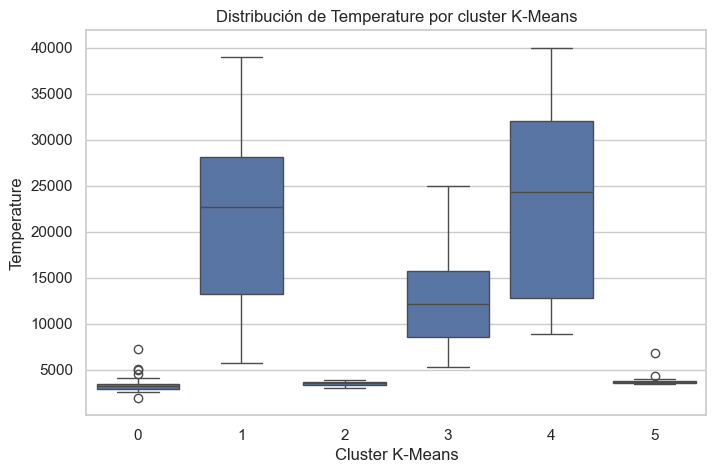

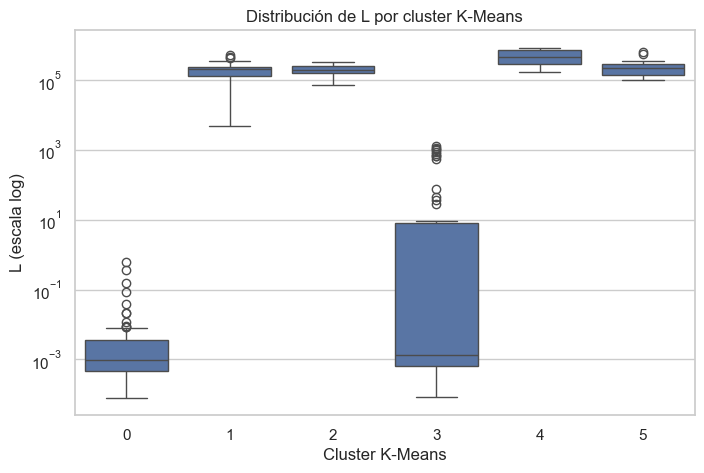

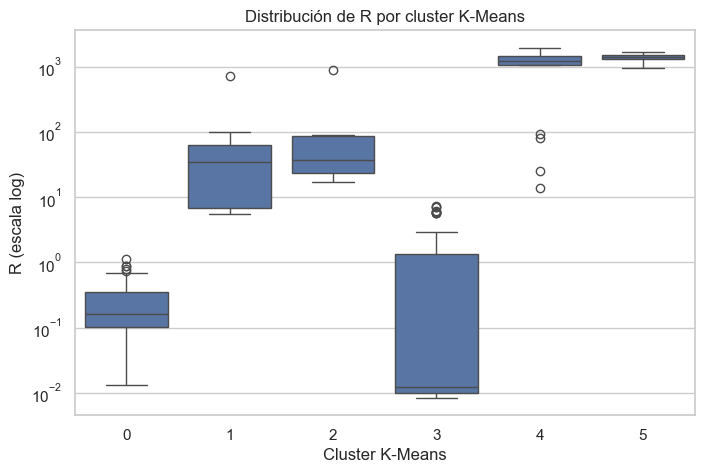

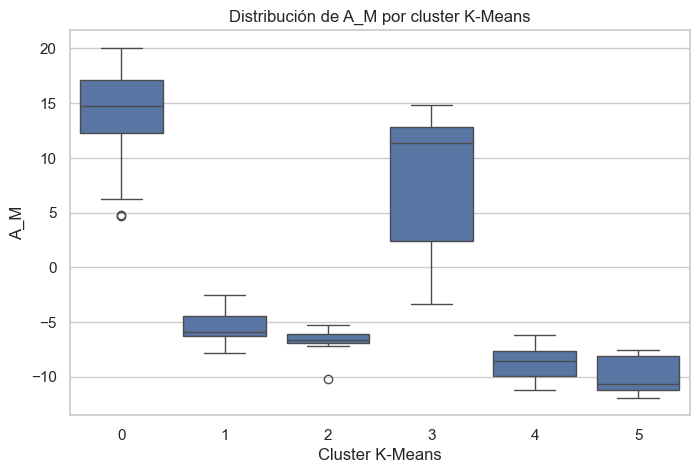

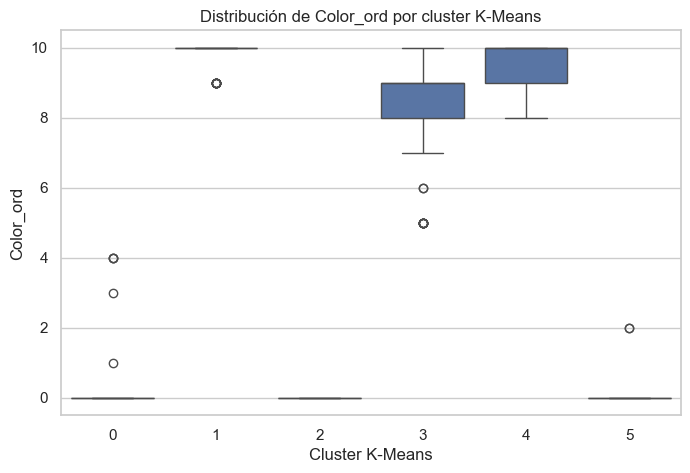

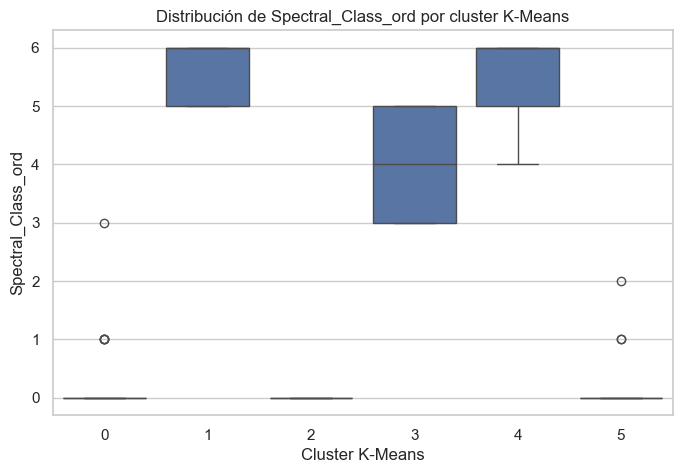

In [43]:
variables_boxplot = ["Temperature", "L", "R", "A_M", "Color_ord", "Spectral_Class_ord"]

for var in variables_boxplot:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df_clusters,
        x="Cluster_KMeans",
        y=var
    )
    
    if var in ["L", "R"]:
        plt.yscale("log")
        plt.ylabel(f"{var} (escala log)")
    else:
        plt.ylabel(var)
    
    plt.title(f"Distribución de {var} por cluster K-Means")
    plt.xlabel("Cluster K-Means")
    plt.show()

**Conclusión:**  
Los boxplots muestran que los clusters presentan diferencias claras en variables como temperatura, luminosidad, radio y magnitud absoluta. En particular, algunos grupos concentran estrellas frías y poco luminosas, mientras que otros agrupan estrellas mucho más luminosas, grandes o calientes. Esto confirma que los clusters obtenidos por K-Means representan perfiles físicos distintos.

### 7.3 Interpretación de los clusters obtenidos

A partir de la tabla resumen y de los boxplots, se interpreta el perfil físico de cada cluster obtenido con K-Means. Esta comparación se realiza de forma aproximada, ya que los grupos han sido obtenidos mediante aprendizaje no supervisado y no tienen por qué coincidir exactamente con las clases astronómicas de referencia.

| Cluster | Perfil observado | Interpretación aproximada |
|---|---|---|
| 0 | Estrellas frías, rojas, de baja luminosidad, radio pequeño y magnitud absoluta alta. | Similar a enanas rojas. |
| 1 | Estrellas muy calientes, azules, muy luminosas, con radio elevado y magnitud absoluta negativa. | Similar a estrellas masivas luminosas, cercanas a supergigantes azules o estrellas de secuencia principal muy luminosas. |
| 2 | Estrellas frías y rojas, pero con luminosidad y radio muy altos. | Similar a gigantes o supergigantes rojas. |
| 3 | Estrellas calientes, de color azul-blanco, baja luminosidad, radio muy pequeño y magnitud absoluta positiva. | Similar a enanas blancas. |
| 4 | Estrellas muy calientes, azules, extremadamente luminosas y con radios muy grandes. | Similar a supergigantes o hipergigantes. |
| 5 | Estrellas frías y rojas, extremadamente luminosas, con radios muy grandes y magnitud absoluta muy negativa. | Similar a supergigantes rojas o hipergigantes rojas. |

**Conclusión:**  
Los clusters obtenidos presentan perfiles físicos diferenciados. Algunos grupos se corresponden bastante bien con clases astronómicas esperadas, como las enanas rojas o las enanas blancas. Otros clusters agrupan estrellas mucho más luminosas y de mayor radio, que pueden relacionarse con gigantes, supergigantes o hipergigantes. Aunque la correspondencia no es exacta, los resultados muestran que el clustering ha capturado patrones coherentes con las propiedades físicas de las estrellas.

## 8. Conclusiones finales

En esta práctica se ha aplicado un pipeline completo de aprendizaje no supervisado para agrupar estrellas según sus características físicas y espectrales. Tras realizar el EDA, limpiar y codificar las variables categóricas ordinales, estandarizar los datos y aplicar PCA a dos componentes, se compararon K-Means, clustering jerárquico y DBSCAN.

El pipeline recomendado fue K-Means con `k = 6`, ya que ofreció una buena separación de los grupos, un valor de silhouette superior al del clustering jerárquico y una partición interpretable. DBSCAN resultó útil para detectar posibles observaciones aisladas, aunque al generar menos clusters y marcar parte de los datos como ruido, se consideró menos adecuado como pipeline principal.

La caracterización posterior de los clusters mostró similitudes razonables con varias clases astronómicas, como enanas rojas, enanas blancas, supergigantes e hipergigantes. Aunque la correspondencia no es exacta, los grupos obtenidos reflejan patrones coherentes con las propiedades físicas de las estrellas.